# Group 5 - Member 2: Local Instance Explanations & Customer Risk Stratification

This notebook develops the local explainability engine, assigns customer risk tiers, and extracts personalized drivers for individual customers.

### Key Objectives:
1. Stratify customers into **Low Risk** (<30%), **Medium Risk** (30-60%), and **High Risk** (>=60%).
2. Decompose individual predictions into positive (risk-increasing) and negative (mitigating) factors.
3. Generate local waterfall charts for exemplar customer profiles (e.g. C0001, C0002, C0007).
4. Profile the high-risk cohort to identify systemic risk patterns across customer demographics and subscriptions.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()
SRC_DIR = CURRENT_DIR.parent / "src" if CURRENT_DIR.name == "notebooks" else CURRENT_DIR / "src"
sys.path.insert(0, str(SRC_DIR))

from explainers import ChurnModelExplainer
from risk_profiler import CustomerRiskProfiler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

## 1. Load Data and Initialize Risk Profiler

In [2]:
DATA_PATH = Path("../Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../../Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("Feature Engineering & Statistical Analysis/outputs/customer_churn_feature_engineered.csv")

df = pd.read_csv(DATA_PATH)

CORE_FEATURES = [
    "Senior Citizen", "Partner", "Dependents", "Tenure Months", "Multiple Lines",
    "Internet Service", "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies", "Contract",
    "Paperless Billing", "Payment Method", "Monthly Charges", "Total Charges",
    "Fiber_Monthly_Risk", "New_High_Spend", "New_Monthly_Customer", "Security_Tech_Bundle"
]
TARGET = "Churn Value"

X = df[CORE_FEATURES].copy()
y = df[TARGET].copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("categorical", Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)
    ],
    remainder="drop"
)

clf = LogisticRegression(C=0.1, class_weight="balanced", solver="lbfgs", max_iter=2000, random_state=42)
pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
pipeline.fit(X, y)

explainer = ChurnModelExplainer(pipeline, feature_names=CORE_FEATURES, background_data=X)
profiler = CustomerRiskProfiler(explainer)

## 2. Customer Risk Categorization & Summary

In [3]:
scored_df = profiler.score_and_profile_dataset(df, CORE_FEATURES)
risk_summary = profiler.compute_risk_summary(scored_df, df_original=df)
risk_summary

,Risk_Category,Customer_Count,Mean_Churn_Prob,Min_Churn_Prob,Max_Churn_Prob,Percentage,Avg_Monthly_Charges,Avg_Tenure_Months,Avg_Total_Charges,Actual_Churn_Rate
0,High Risk,2328,78.35,0.6,0.96,33.05,77.04,14.34,1270.38,58.25
1,Low Risk,3217,11.30,0.0,0.30,45.68,55.75,47.00,2951.87,4.54
2,Medium Risk,1498,45.92,0.3,0.60,21.27,65.03,28.99,2404.92,24.50


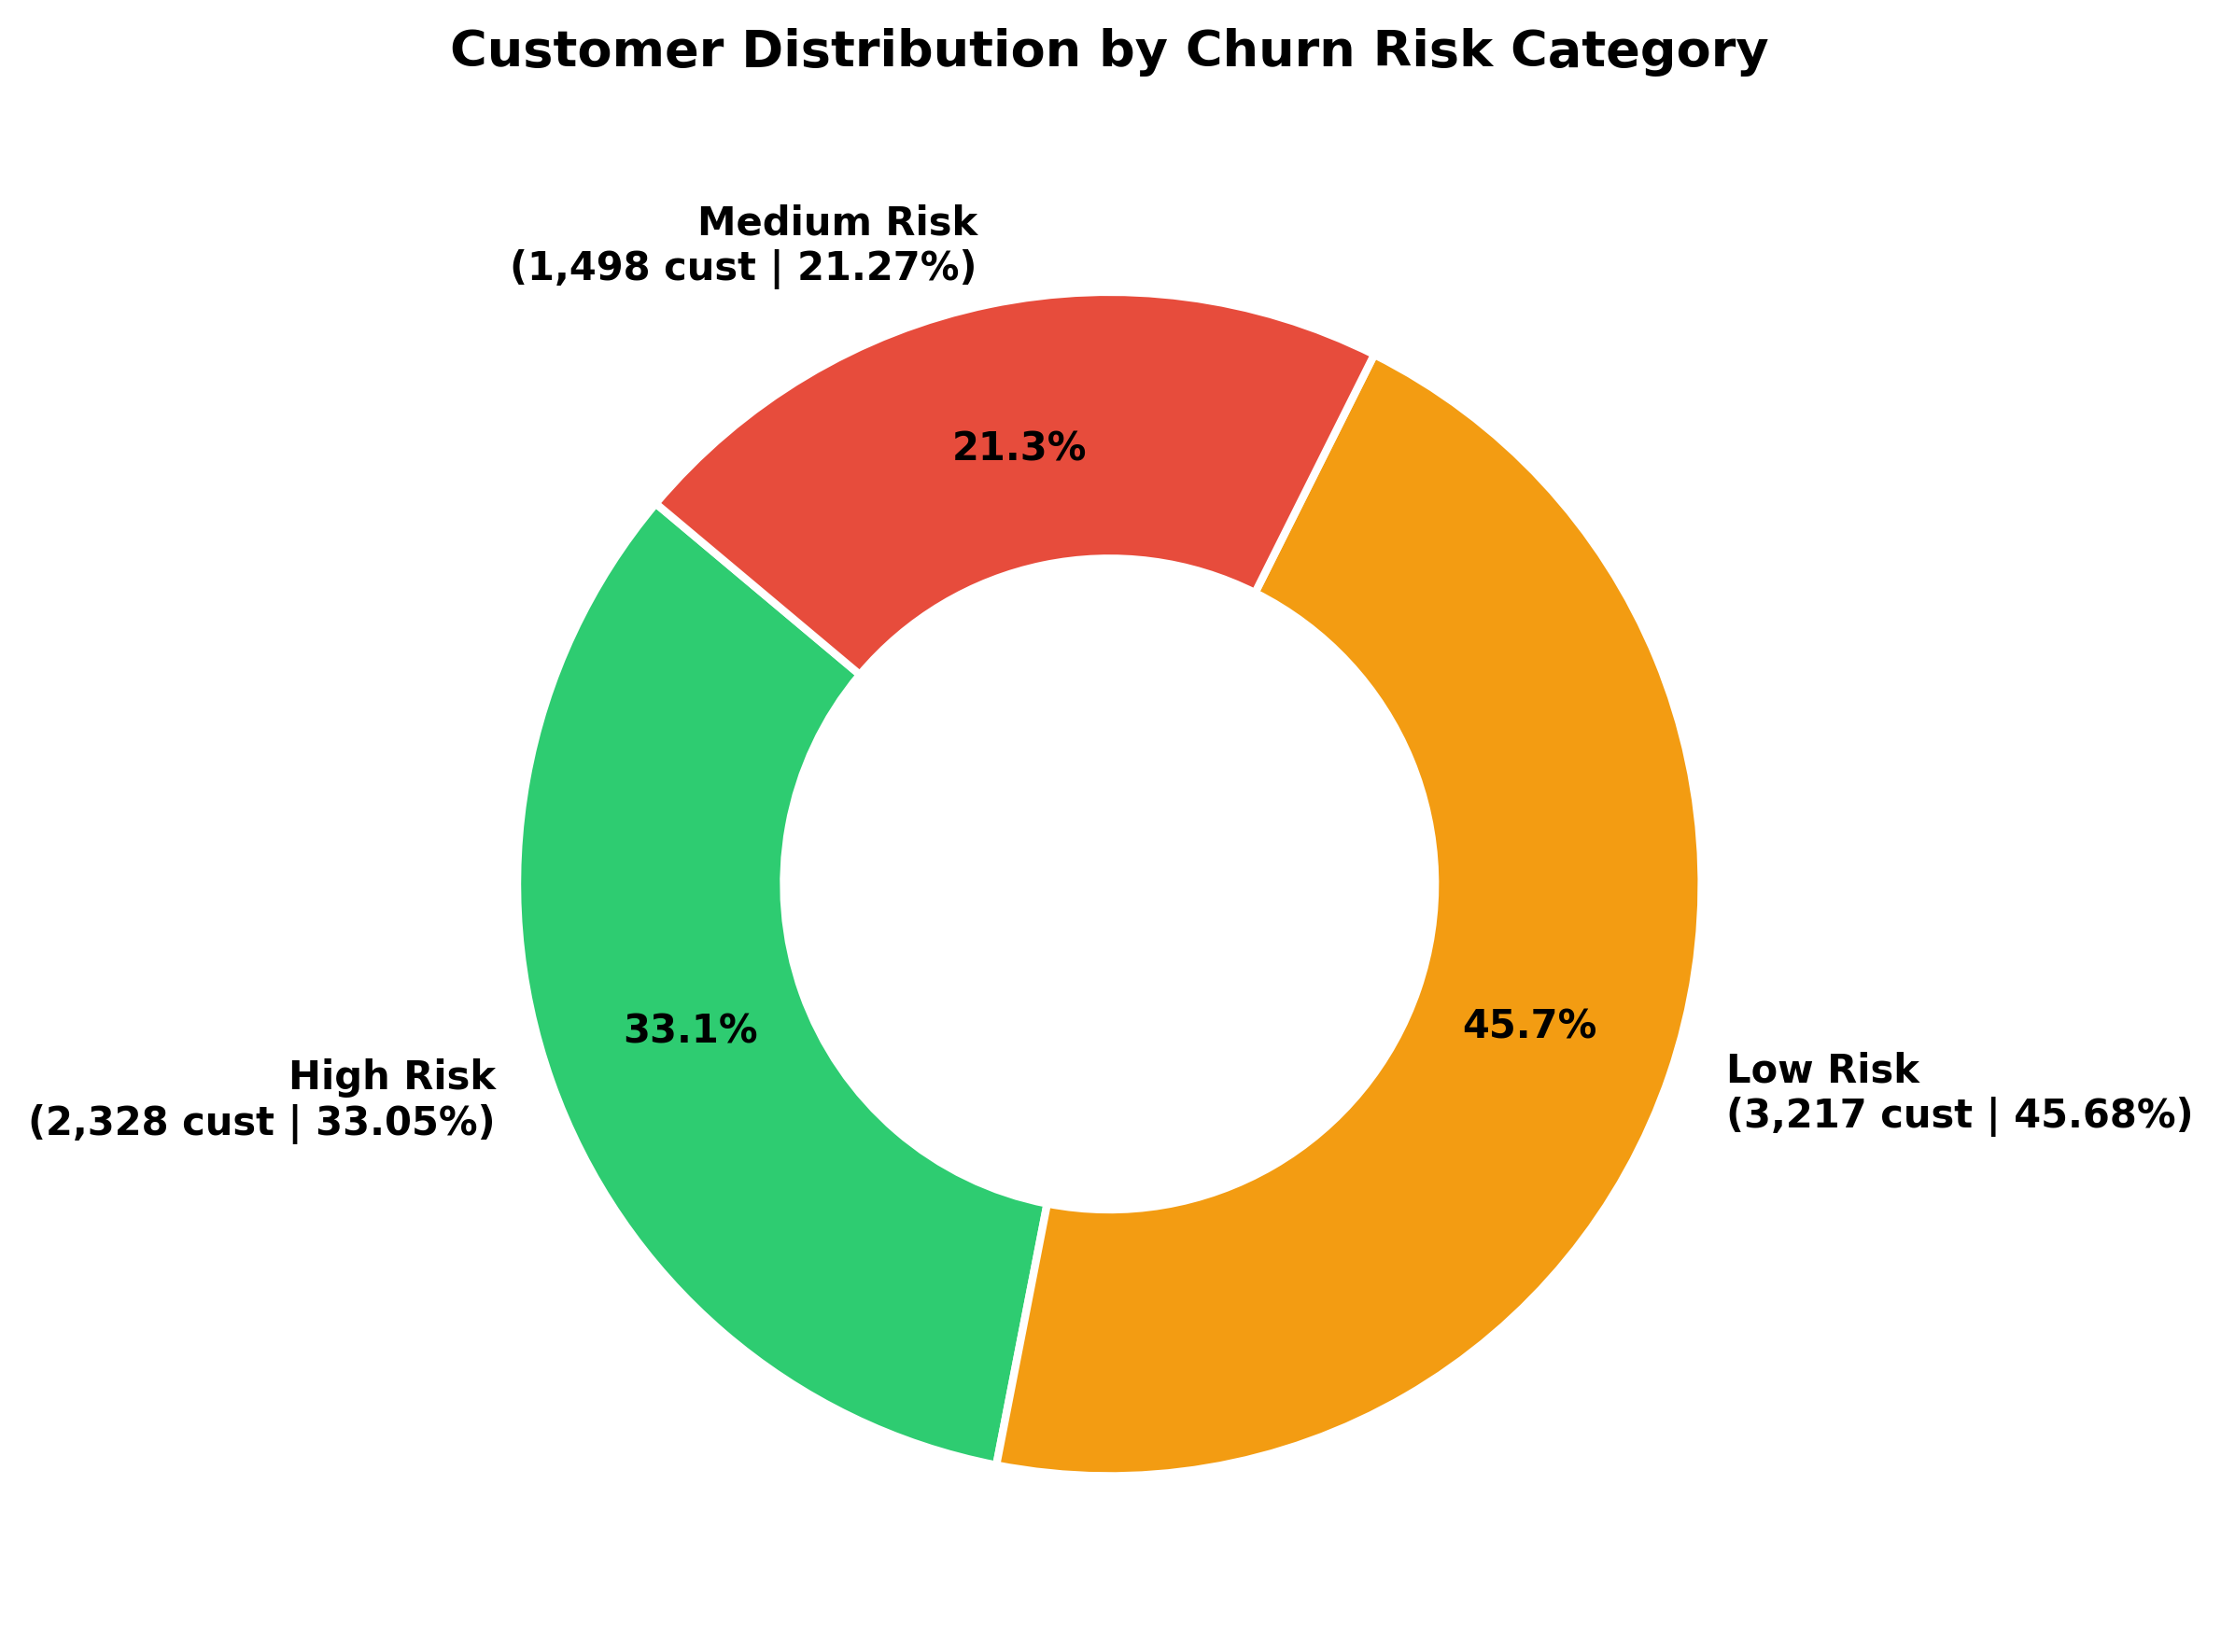

In [4]:
profiler.plot_risk_distribution(risk_summary)

## 3. High-Risk Customer Driver Analysis

In [5]:
high_risk_factors = profiler.analyze_high_risk_factors(scored_df)
high_risk_factors.head(10)

,Driver,Primary_Count,Total_Occurrences_In_Top3,High_Risk_Prevalence_Pct
0,Internet Service_Fiber optic,810.0,1743,74.87
1,Tenure Months,1500.0,1726,74.14
2,Dependents,18.0,1437,61.73
3,New_Monthly_Customer,0.0,1422,61.08
4,Contract_Month-to-month,0.0,624,26.80
5,Streaming TV,0.0,27,1.16
6,Total Charges,0.0,3,0.13
7,Internet Service_No,0.0,1,0.04
8,Streaming Movies,0.0,1,0.04


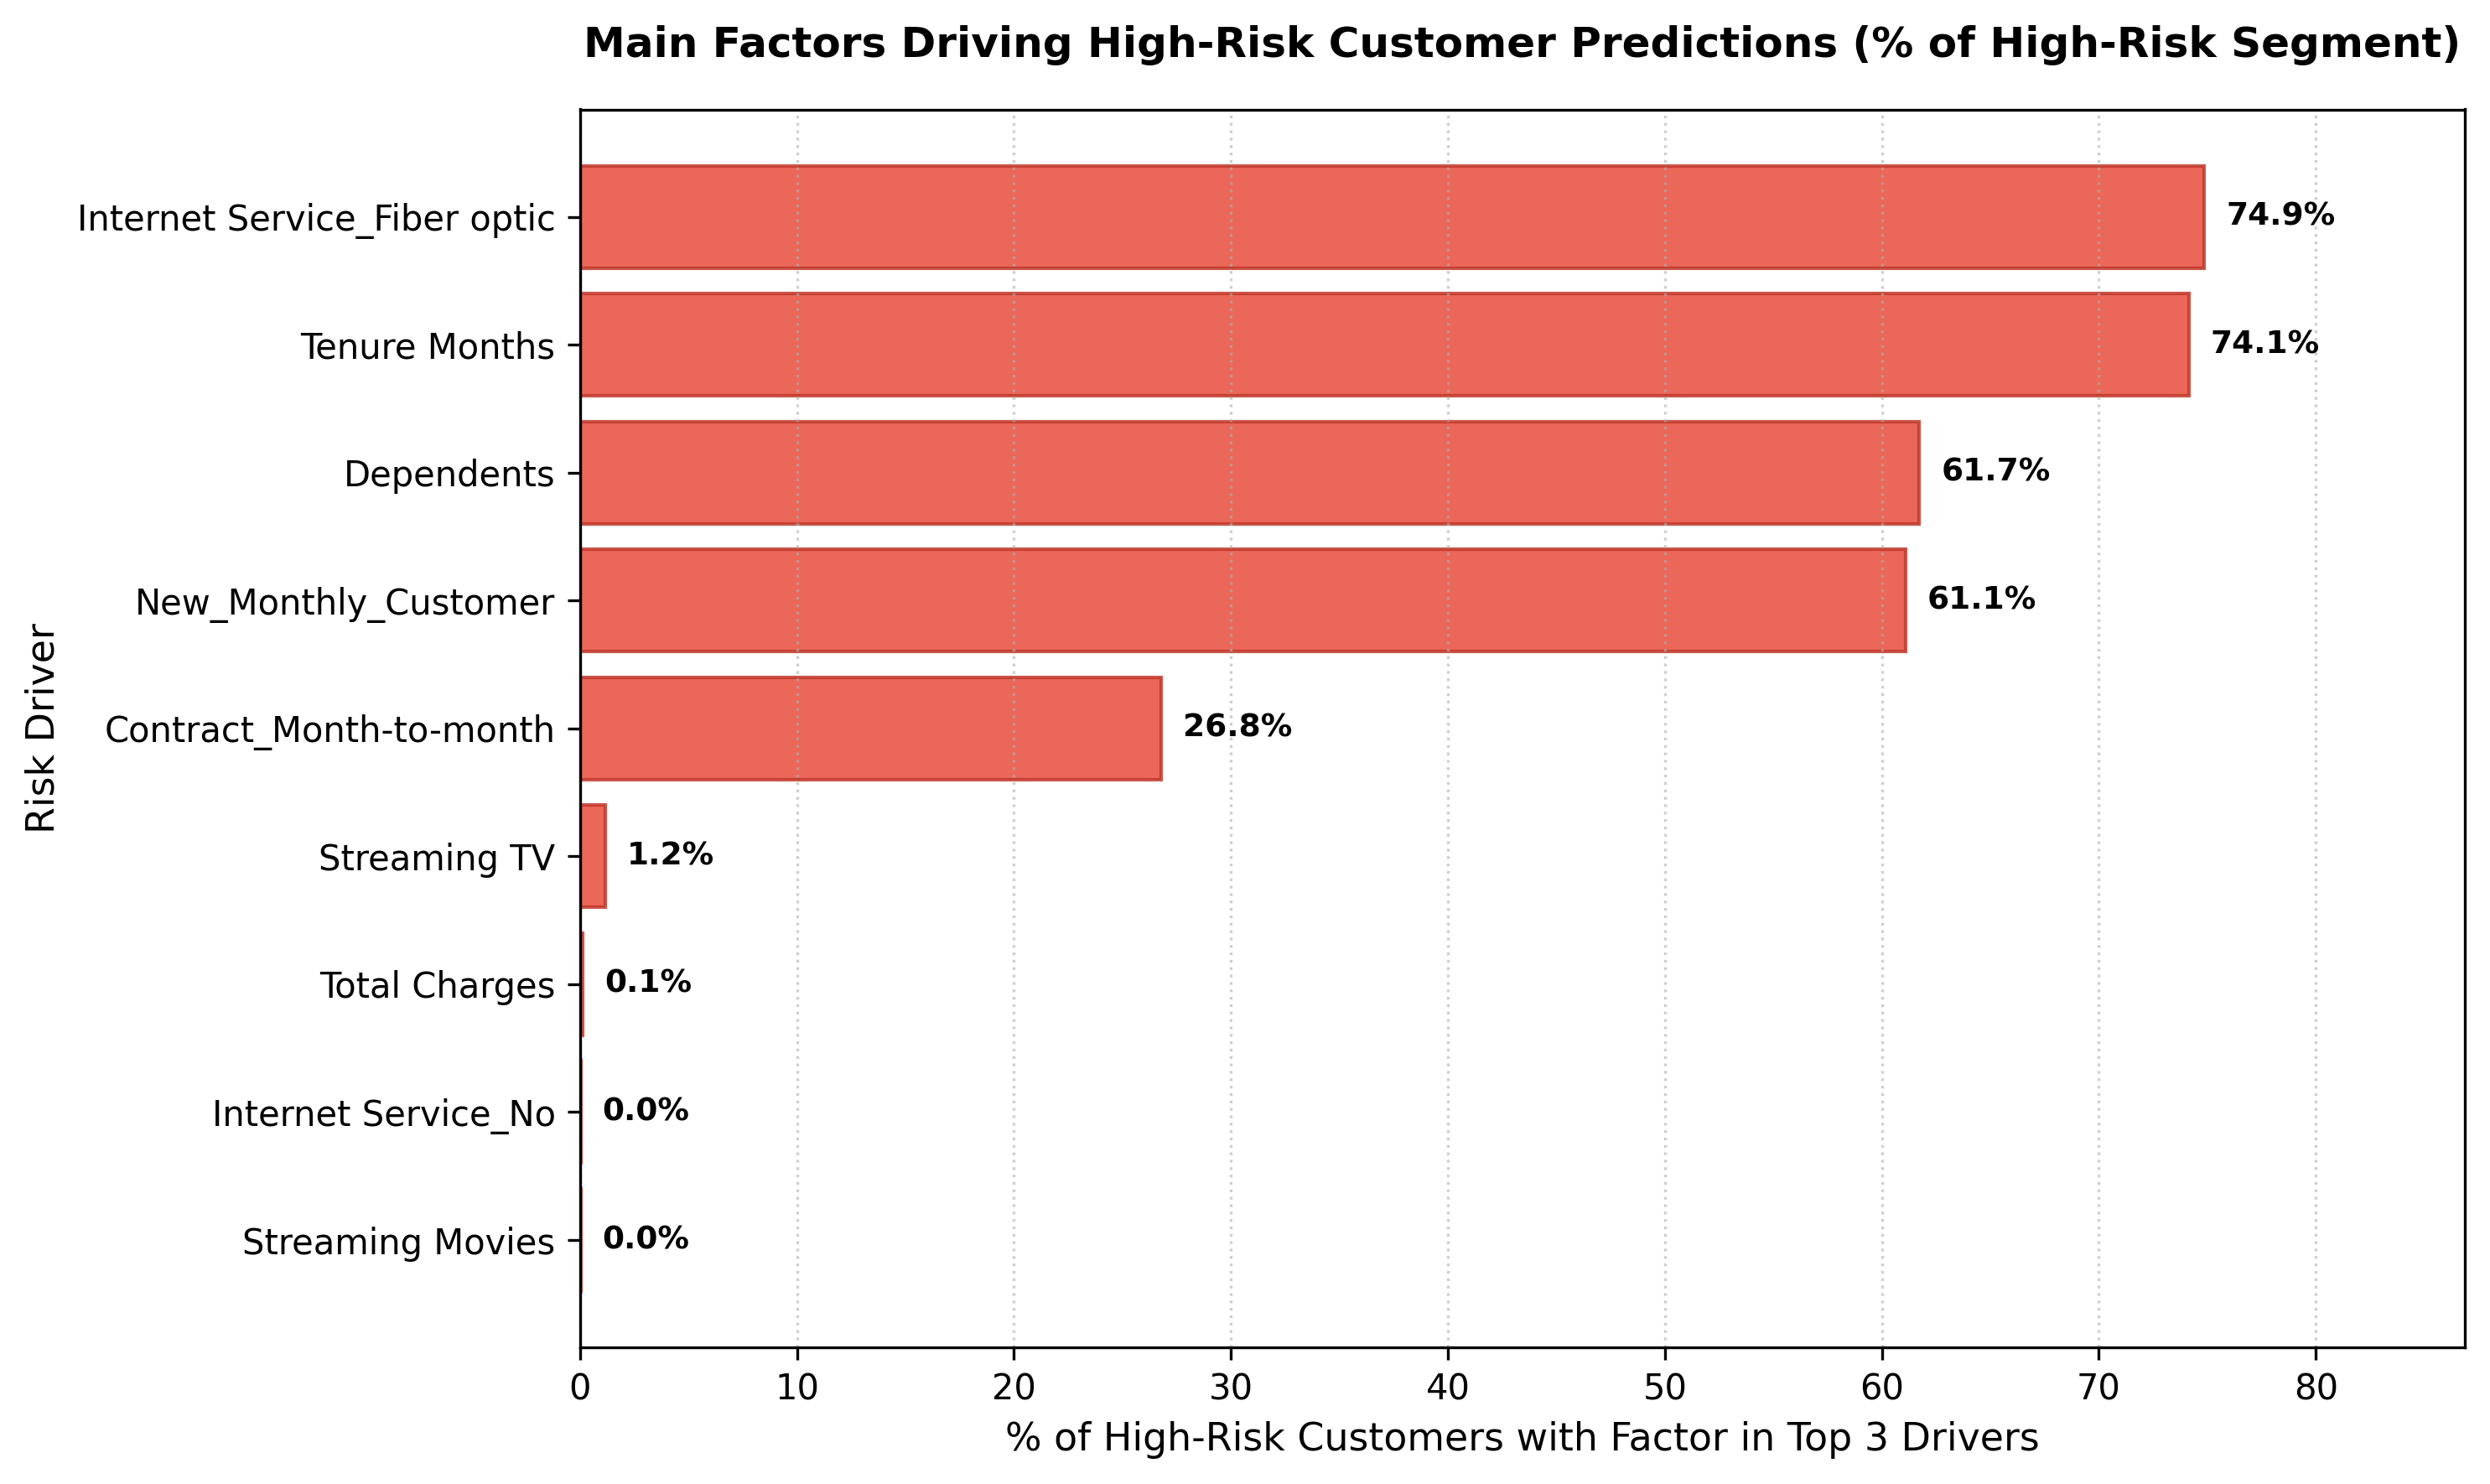

In [6]:
profiler.plot_high_risk_drivers(high_risk_factors, top_n=10)

## 4. Local Individual Waterfall Explanations (Exemplars)

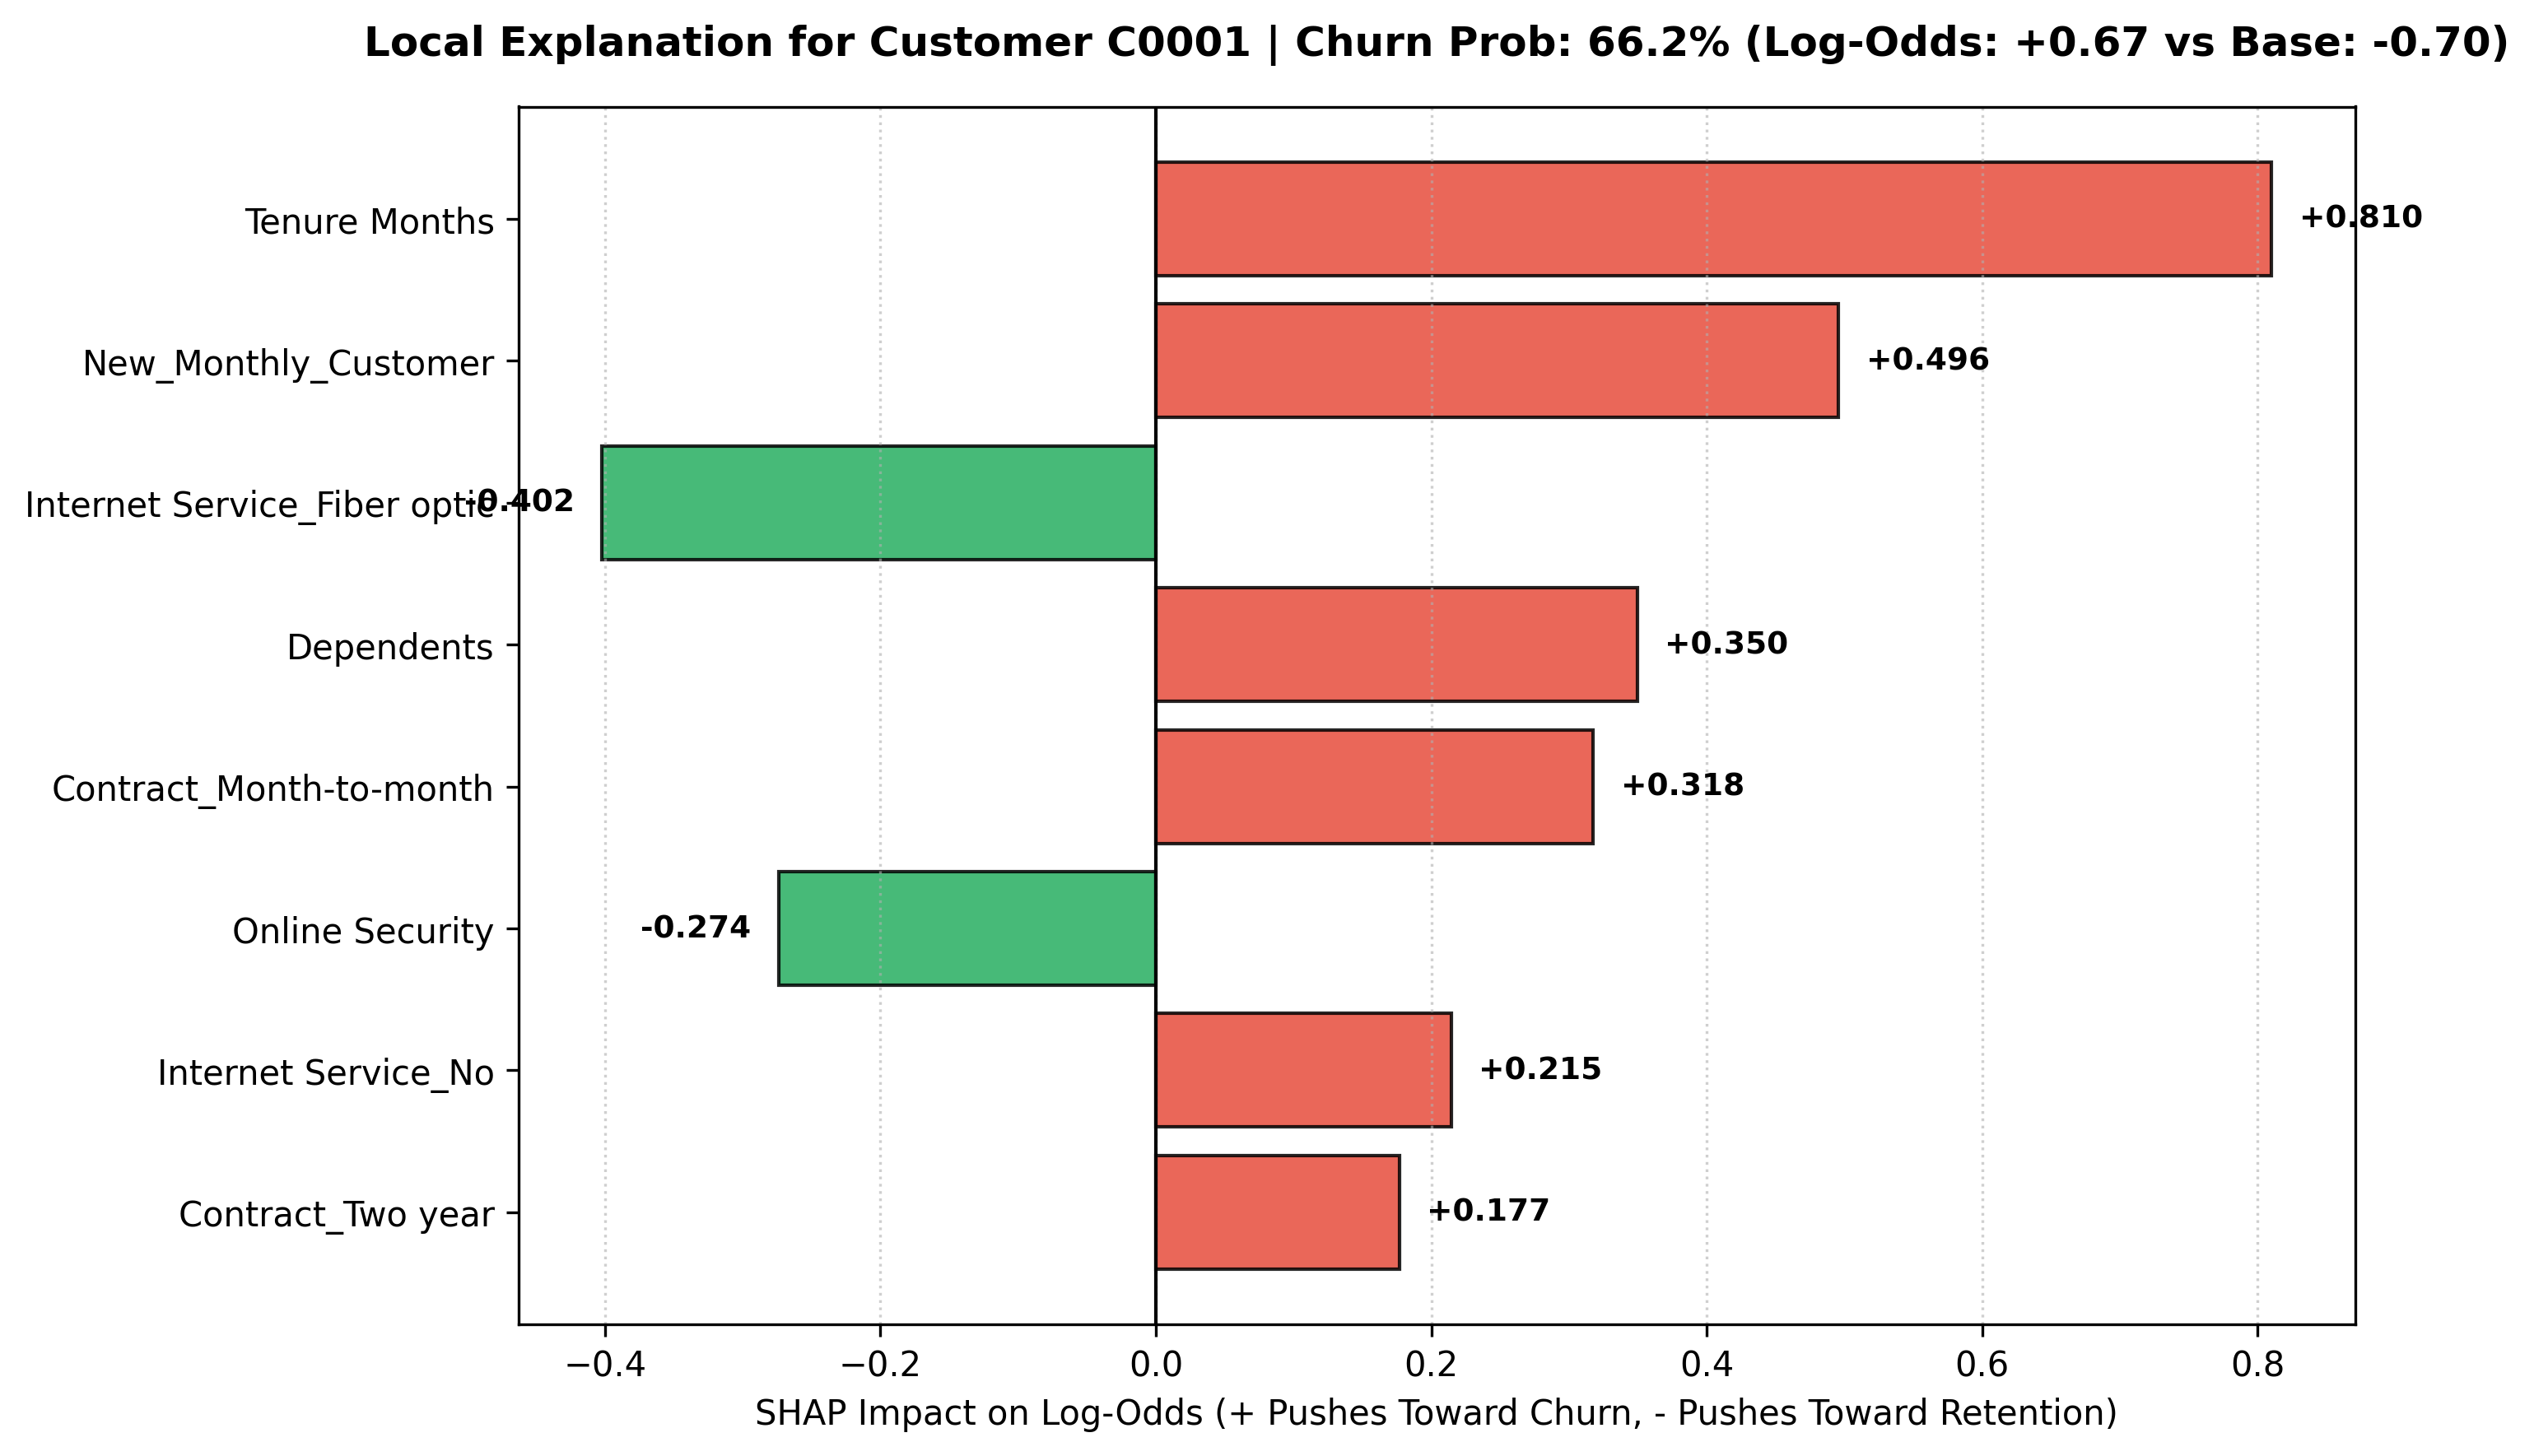

In [7]:
explainer.plot_waterfall(X.iloc[0], customer_id="Customer C0001", max_display=8)

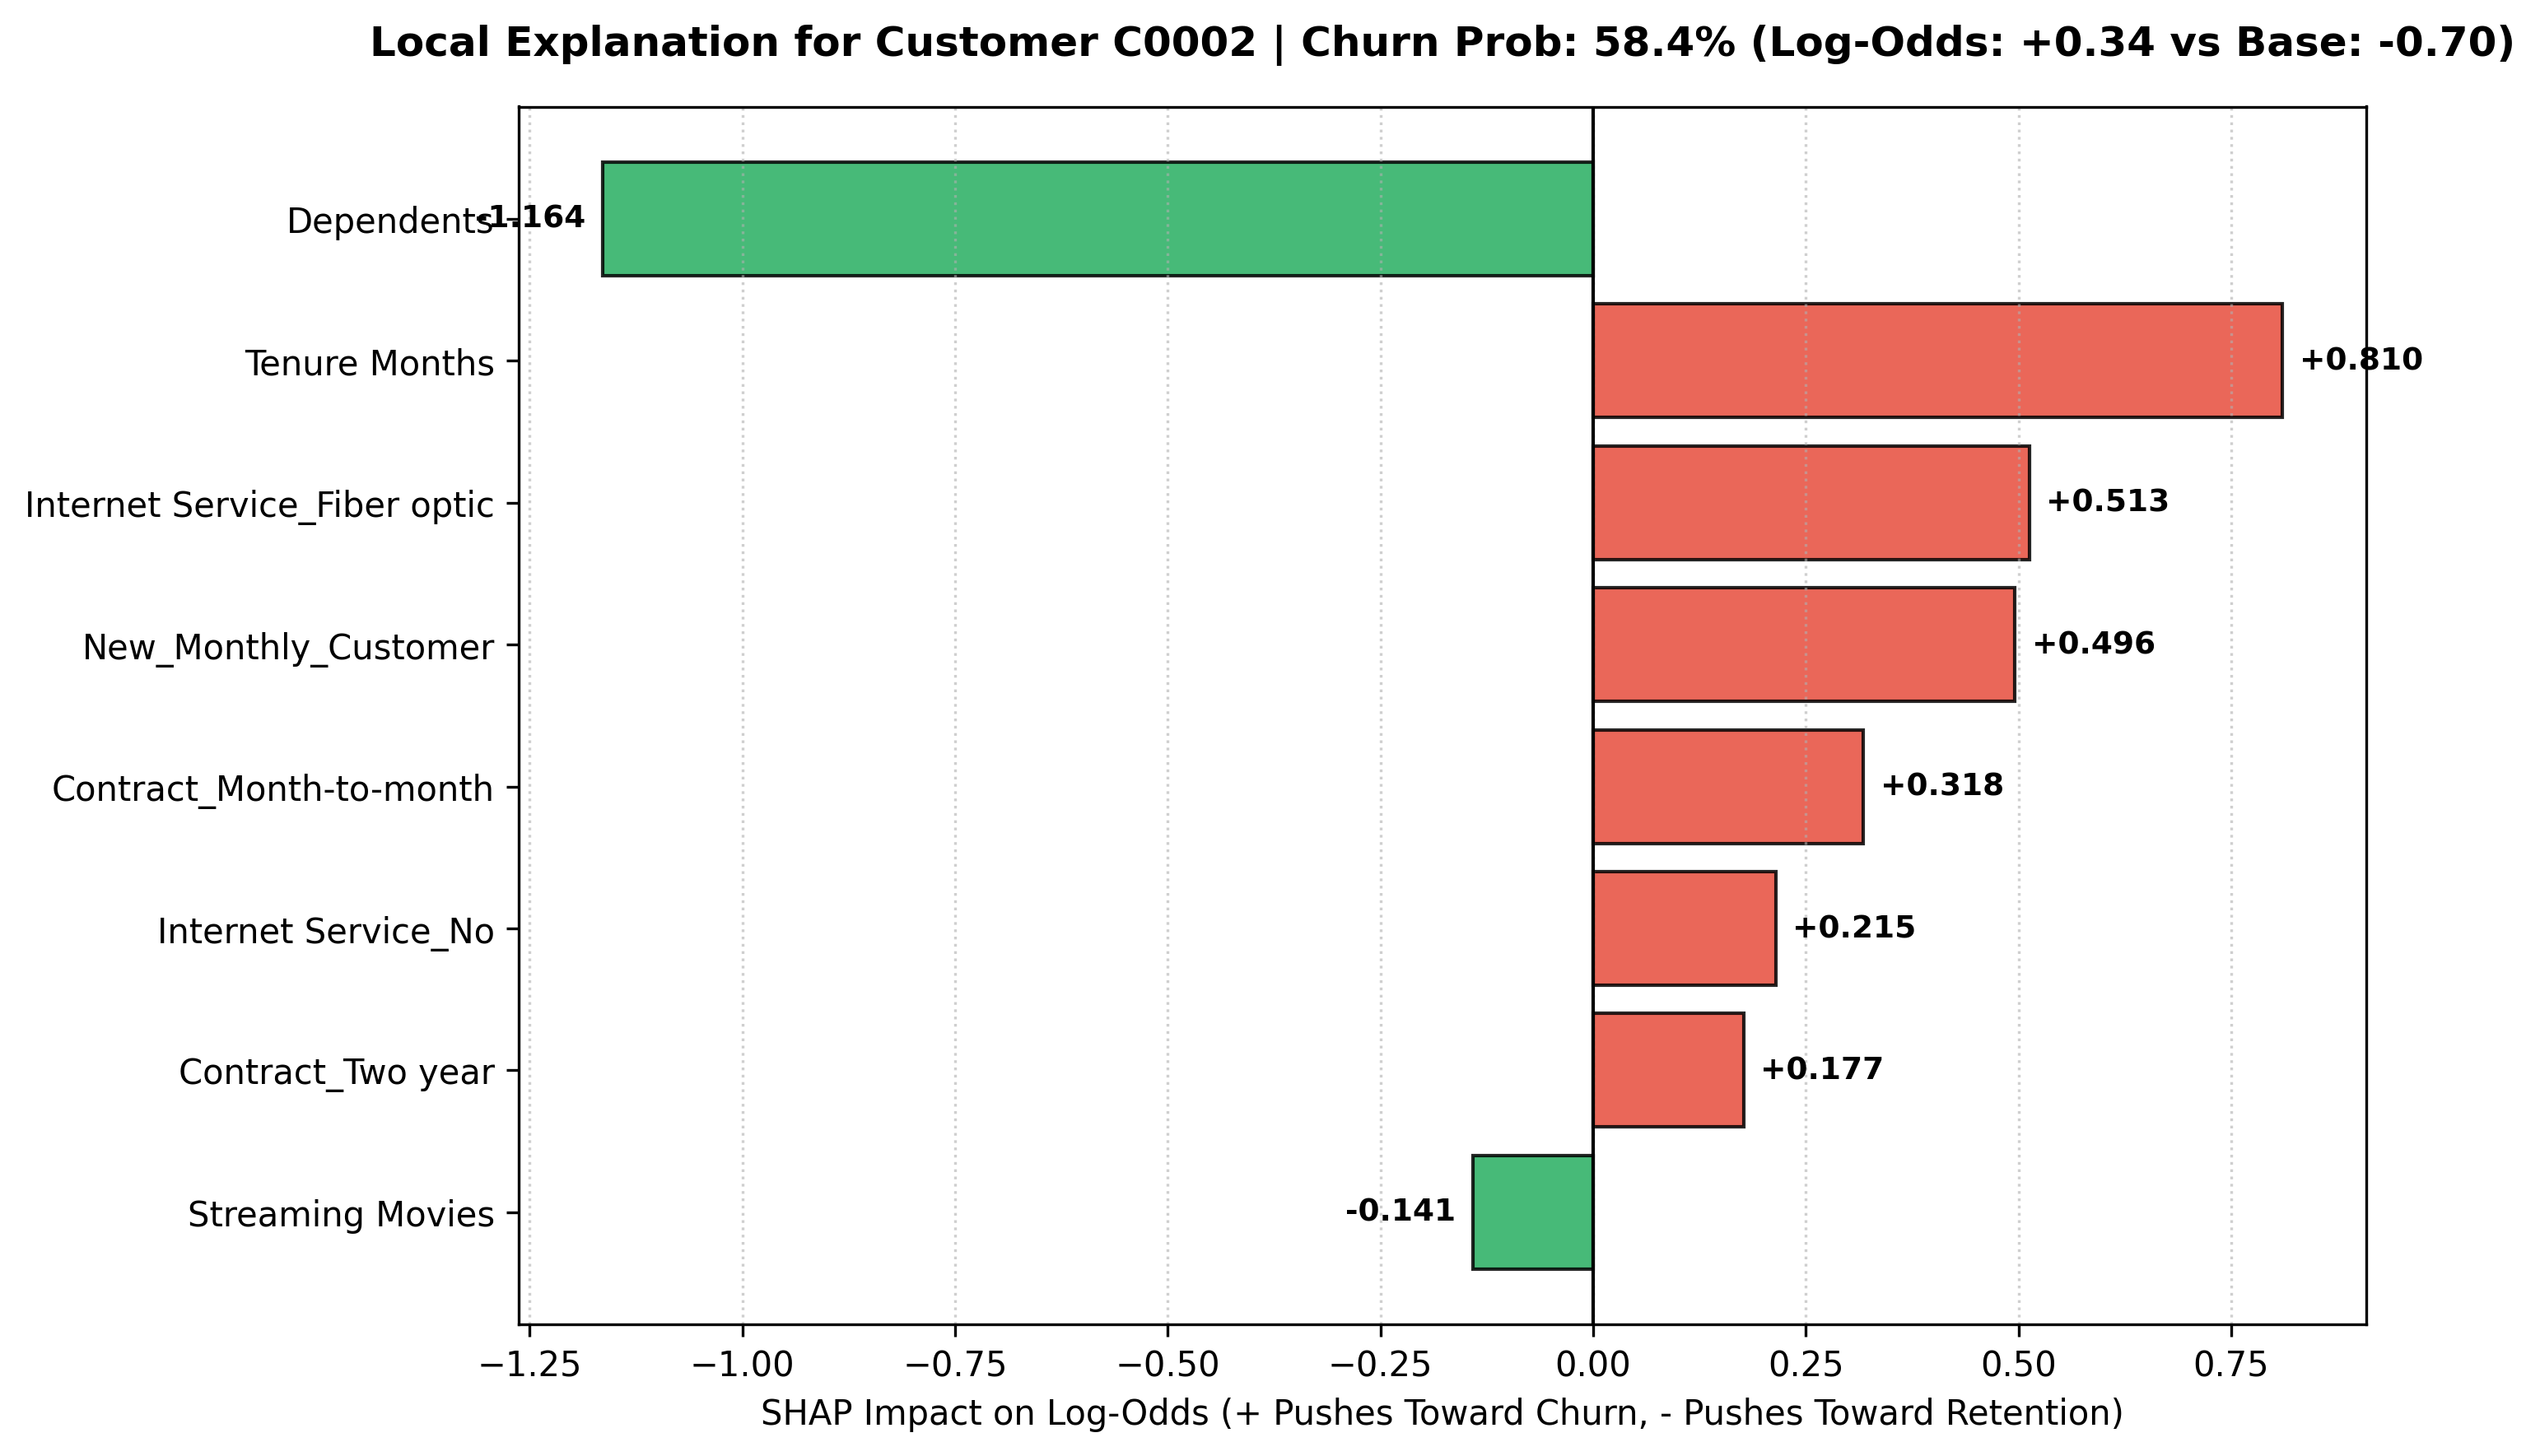

In [8]:
explainer.plot_waterfall(X.iloc[1], customer_id="Customer C0002", max_display=8)

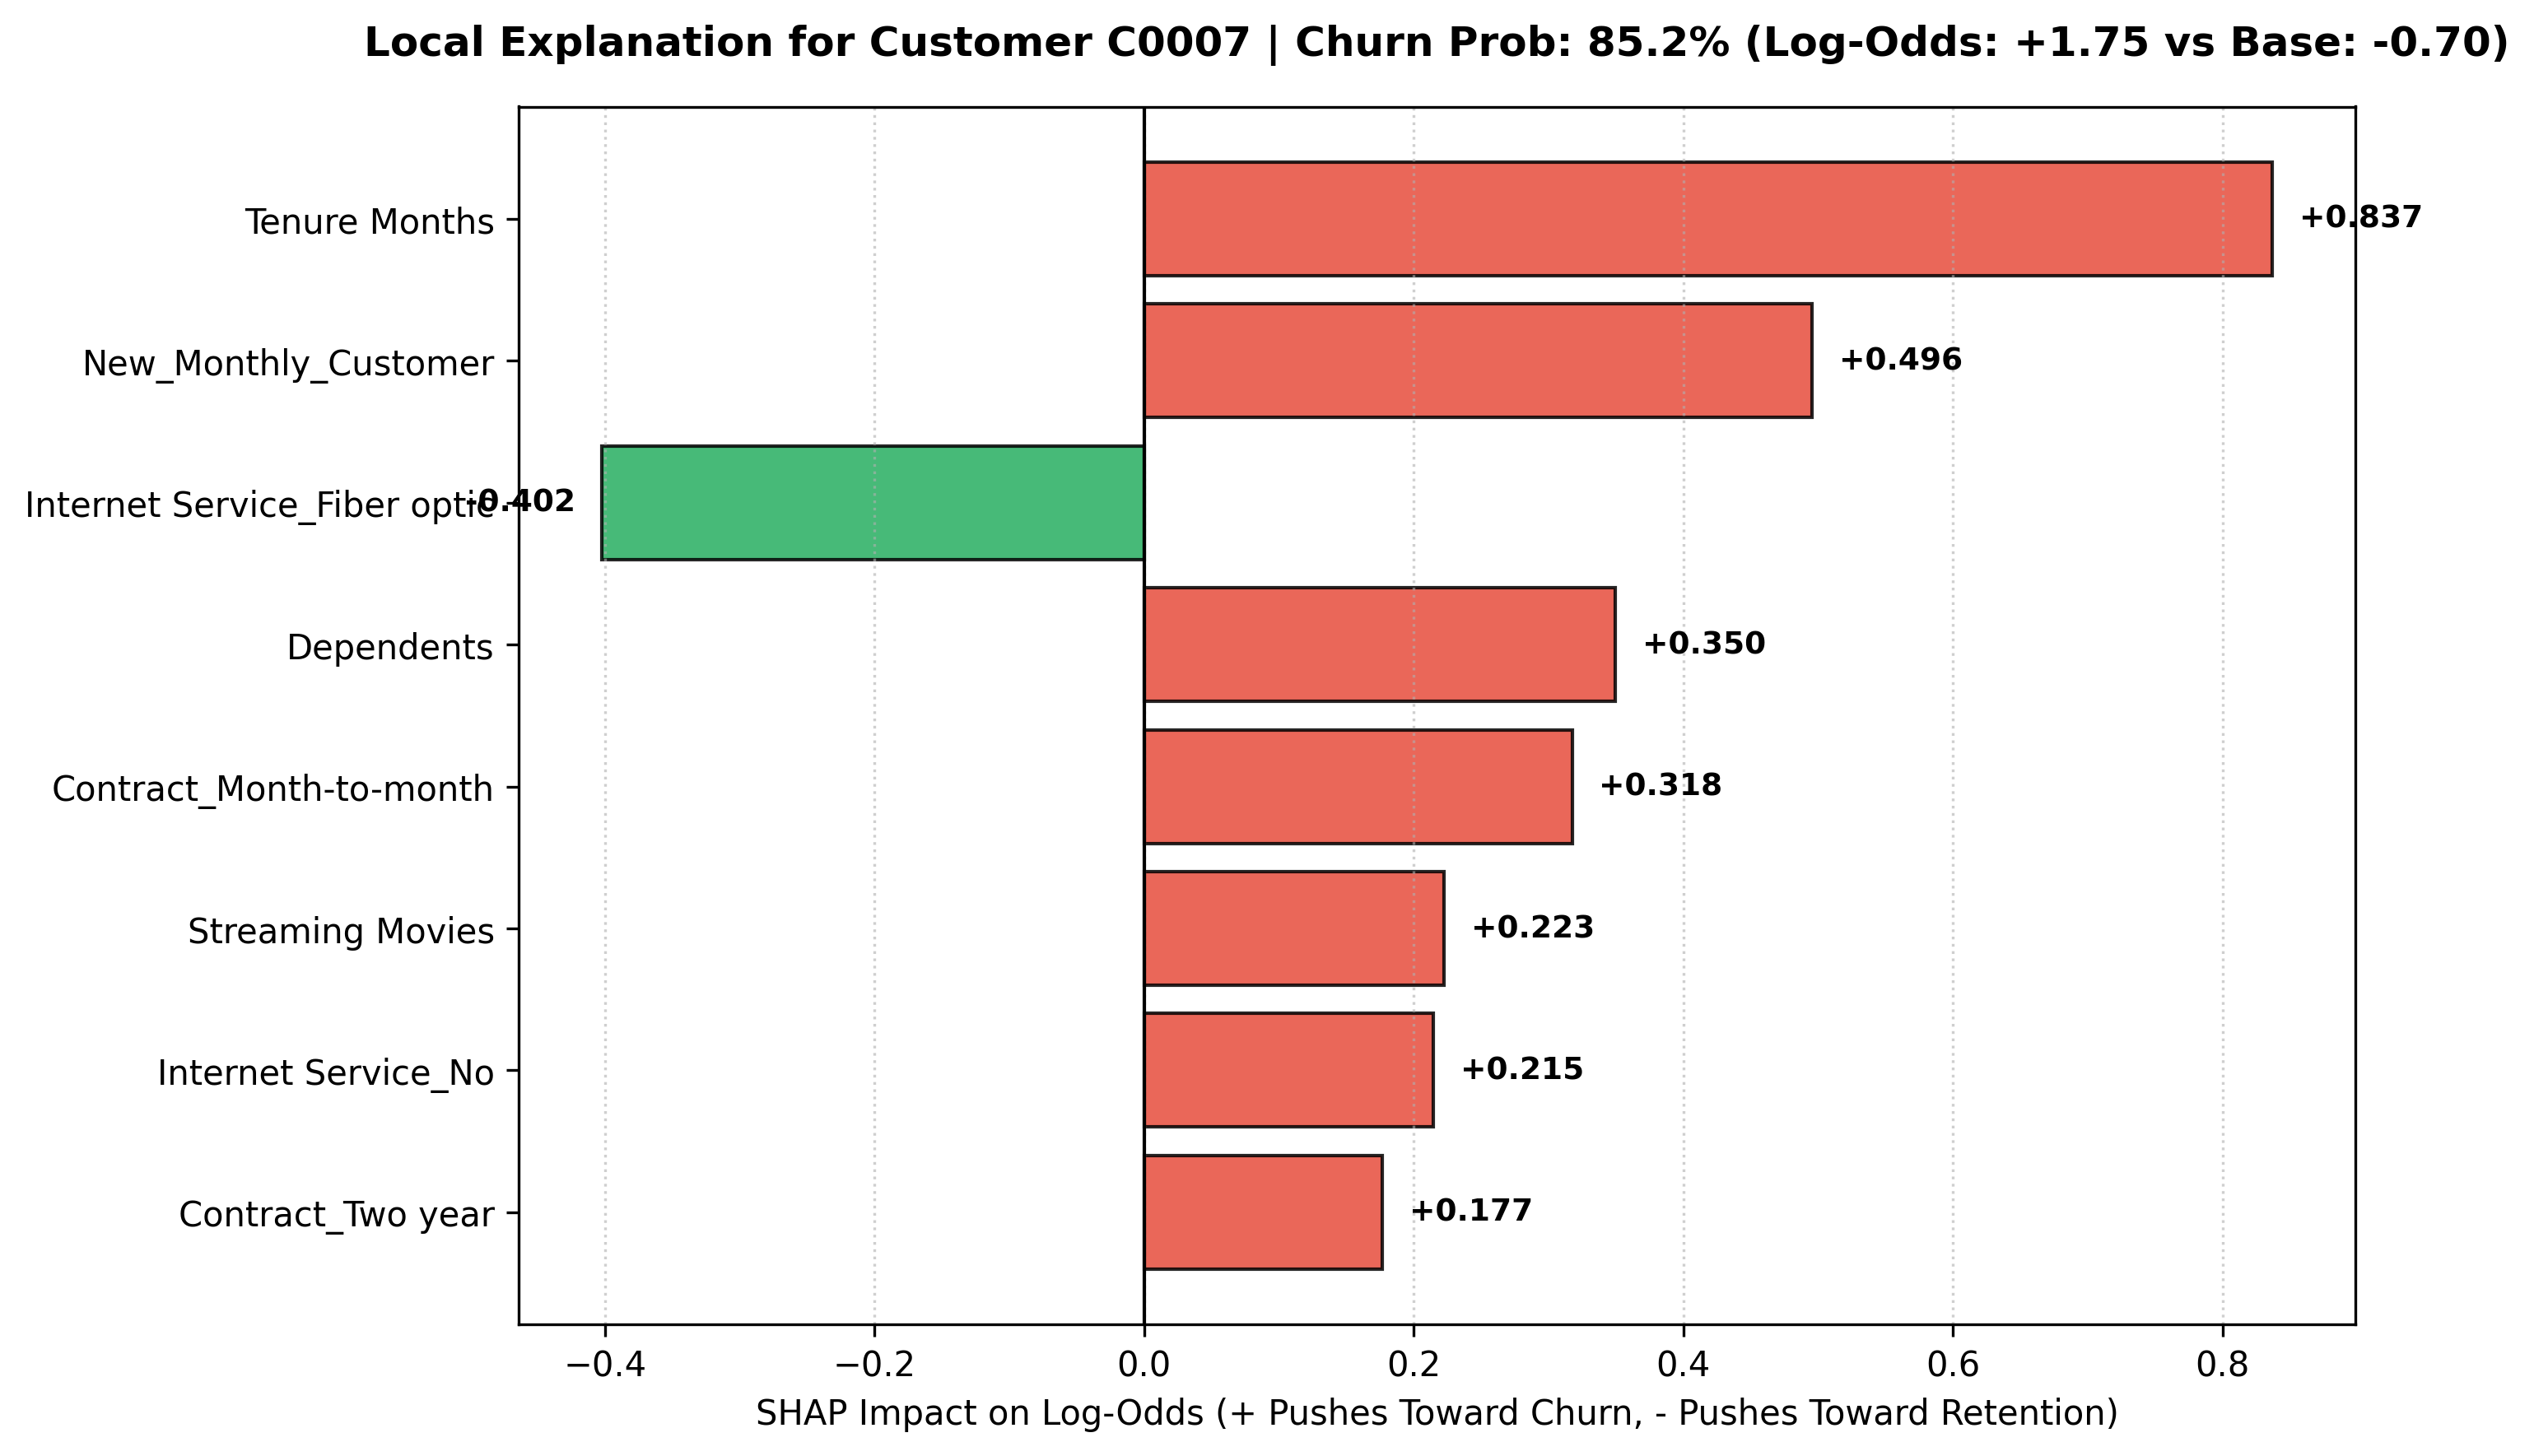

In [9]:
explainer.plot_waterfall(X.iloc[6], customer_id="Customer C0007", max_display=8)